In [24]:
from pathlib import Path
from itertools import permutations

import joblib
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Fester Seed für reproduzierbare Random-Search-Ergebnisse.
SEED = 83376
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# Projekt-Root robust finden
ROOT = Path.cwd().resolve()
for p in [ROOT] + list(ROOT.parents):
    if (p / "pyproject.toml").exists():
        ROOT = p
        break

# Echte, bekannte ROI-Zentren (Ground Truth)
TRUE_ROIS = np.array([
    [0.2928, 0.8067],
    [0.4349, 0.8067],
    [0.5668, 0.8034],
    [0.7280, 0.6786],
], dtype=float)

N_TRIALS = 100
print(f"Using fixed seed: {SEED}")

Using fixed seed: 83376


In [25]:
with (ROOT / "configs" / "models" / "hmm.yaml").open("r", encoding="utf-8") as f:
    hmm_cfg = yaml.safe_load(f)
with (ROOT / "configs" / "models" / "gmm.yaml").open("r", encoding="utf-8") as f:
    gmm_cfg = yaml.safe_load(f)

raw_data_dir = ROOT / gmm_cfg["paths"]["raw_data_dir"]
hmm_model_dir = ROOT / hmm_cfg["paths"]["model_dir"]
grasp_state = int(hmm_cfg["grasp_state"])
frames_to_take = int(gmm_cfg["frames_to_take"])

model = joblib.load(hmm_model_dir / "hmm_model.pkl")
scaler = joblib.load(hmm_model_dir / "scaler.pkl")


def process_csv(file_path: Path) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=";")
    cols_to_fix = [c for c in df.columns if "x" in c or "y" in c]
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.interpolate(method="linear", limit_direction="both").bfill().ffill().fillna(0)
    return df


def calc_hmm_features(df: pd.DataFrame) -> np.ndarray:
    temp_data = []
    for _, row in df.iterrows():
        l_index = np.array([row["l_x_8"], row["l_y_8"]])
        r_index = np.array([row["r_x_8"], row["r_y_8"]])
        l_thumb = np.array([row["l_x_4"], row["l_y_4"]])
        r_thumb = np.array([row["r_x_4"], row["r_y_4"]])

        hand_dist = np.linalg.norm(l_index - r_index)
        mean_pinch = (np.linalg.norm(l_index - l_thumb) + np.linalg.norm(r_index - r_thumb)) / 2
        max_reach_y = max(l_index[1], r_index[1])
        temp_data.append((hand_dist, mean_pinch, max_reach_y))

    feat_df = pd.DataFrame(temp_data, columns=["hand_dist", "mean_pinch", "max_reach_y"])
    feat_df["delta"] = feat_df["hand_dist"].diff().fillna(0).rolling(window=3, center=True).mean().fillna(0)
    return feat_df[["hand_dist", "mean_pinch", "max_reach_y", "delta"]].values


def collect_points() -> np.ndarray:
    all_points = []
    csvs = sorted(raw_data_dir.glob("*.csv"))

    for csv_path in csvs:
        df = process_csv(csv_path)
        X_hmm = calc_hmm_features(df)
        states = model.predict(scaler.transform(X_hmm))

        states_padded = np.append(states, -1)
        block_start = 0
        current_state = states[0]

        l_x = df["l_x_8"].values
        l_y = df["l_y_8"].values
        r_x = df["r_x_8"].values
        r_y = df["r_y_8"].values

        for j in range(1, len(states_padded)):
            if states_padded[j] != current_state:
                block_end = j

                if current_state == grasp_state:
                    start_extract = max(block_start, block_end - frames_to_take)

                    l_pts = np.column_stack((l_x[start_extract:block_end], l_y[start_extract:block_end]))
                    r_pts = np.column_stack((r_x[start_extract:block_end], r_y[start_extract:block_end]))

                    active = l_pts if np.mean(l_pts[:, 1]) > np.mean(r_pts[:, 1]) else r_pts
                    valid = active[np.linalg.norm(active, axis=1) > 0.1]
                    if len(valid) > 0:
                        all_points.extend(valid)

                current_state = states_padded[j]
                block_start = j

    return np.array(all_points)


X = collect_points()
print(f"Collected points: {len(X)}")
print(f"Target ROIs: {len(TRUE_ROIS)}")
print(f"grasp_state={grasp_state}, frames_to_take={frames_to_take}")

assert len(X) > 0, "Keine Trainingspunkte gefunden."
assert len(TRUE_ROIS) == 4, "Dieses Notebook erwartet genau 4 ROI-Groundtruth-Zentren."

Collected points: 8976
Target ROIs: 4
grasp_state=7, frames_to_take=5


In [26]:
def best_center_distance(pred_centers: np.ndarray, true_centers: np.ndarray) -> float:
    # Kleine feste Clusteranzahl (4): bruteforce Matching ist schnell und exakt.
    best = np.inf
    for perm in permutations(range(len(pred_centers))):
        aligned = pred_centers[list(perm)]
        dist = np.linalg.norm(aligned - true_centers, axis=1).mean()
        if dist < best:
            best = dist
    return float(best)


def distance_to_score(mean_dist: float, target_dist: float = 0.08) -> float:
    score = 100.0 * (1.0 - mean_dist / target_dist)
    return float(np.clip(score, 0.0, 100.0))


search_space = {
    "covariance_type": ["full", "diag", "tied", "spherical"],
    "n_init": [3, 5, 10, 20, 30],
    "max_iter": [150, 250, 400],
    "reg_covar": [1e-6, 1e-5, 1e-4, 5e-4, 1e-3],
    "init_params": ["kmeans", "k-means++"],
}

results = []
best = None

for trial in range(1, N_TRIALS + 1):
    params = {
        "n_components": 4,
        "covariance_type": str(RNG.choice(search_space["covariance_type"])),
        "n_init": int(RNG.choice(search_space["n_init"])),
        "max_iter": int(RNG.choice(search_space["max_iter"])),
        "reg_covar": float(RNG.choice(search_space["reg_covar"])),
        "init_params": str(RNG.choice(search_space["init_params"])),
        "random_state": int(SEED),
    }

    gmm = GaussianMixture(**params)
    gmm.fit(X)

    centers = gmm.means_.copy()
    order = np.argsort(centers[:, 0])
    centers = centers[order]

    mean_dist = best_center_distance(centers, TRUE_ROIS)
    score = distance_to_score(mean_dist)

    row = {
        "trial": trial,
        "score": score,
        "mean_center_distance": mean_dist,
        "bic": float(gmm.bic(X)),
        "aic": float(gmm.aic(X)),
        **params,
        "centers": centers,
    }
    results.append(row)

    if best is None or row["score"] > best["score"]:
        best = row

results_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
print("Top 10 Trials:")
display(results_df.drop(columns=["centers"]).head(10))

print("\nBest Trial:")
print(results_df.iloc[0][["trial", "score", "mean_center_distance", "covariance_type", "n_init", "max_iter", "reg_covar", "init_params", "random_state"]])
print("\nBest centers:\n", results_df.iloc[0]["centers"])

Top 10 Trials:


,trial,score,mean_center_distance,bic,aic,n_components,covariance_type,n_init,max_iter,reg_covar,init_params,random_state
0,78,58.412519,0.033270,-35319.379428,-35482.732550,4,full,3,400,0.000500,kmeans,83376
1,77,58.412519,0.033270,-35319.379428,-35482.732550,4,full,3,400,0.000500,kmeans,83376
2,52,58.412519,0.033270,-35319.379428,-35482.732550,4,full,5,250,0.000500,kmeans,83376
3,54,58.412519,0.033270,-35319.379428,-35482.732550,4,full,10,150,0.000500,kmeans,83376
4,64,56.678054,0.034658,-36679.121975,-36814.065858,4,diag,30,400,0.000100,kmeans,83376
5,33,56.651176,0.034679,-36869.873474,-37033.226595,4,full,10,250,0.000100,kmeans,83376
6,3,56.651176,0.034679,-36869.873474,-37033.226595,4,full,30,150,0.000100,kmeans,83376
7,4,56.651176,0.034679,-36869.873474,-37033.226595,4,full,5,250,0.000100,kmeans,83376
8,13,56.651176,0.034679,-36869.873474,-37033.226595,4,full,30,150,0.000100,kmeans,83376
9,48,56.616497,0.034707,-36759.573621,-36894.517504,4,diag,3,150,0.000001,kmeans,83376



Best Trial:
trial                          78
score                   58.412519
mean_center_distance      0.03327
covariance_type              full
n_init                          3
max_iter                      400
reg_covar                  0.0005
init_params                kmeans
random_state                83376
Name: 0, dtype: object

Best centers:
 [[0.3181138  0.77156638]
 [0.4355331  0.77941585]
 [0.55355909 0.76737035]
 [0.7040111  0.67629183]]


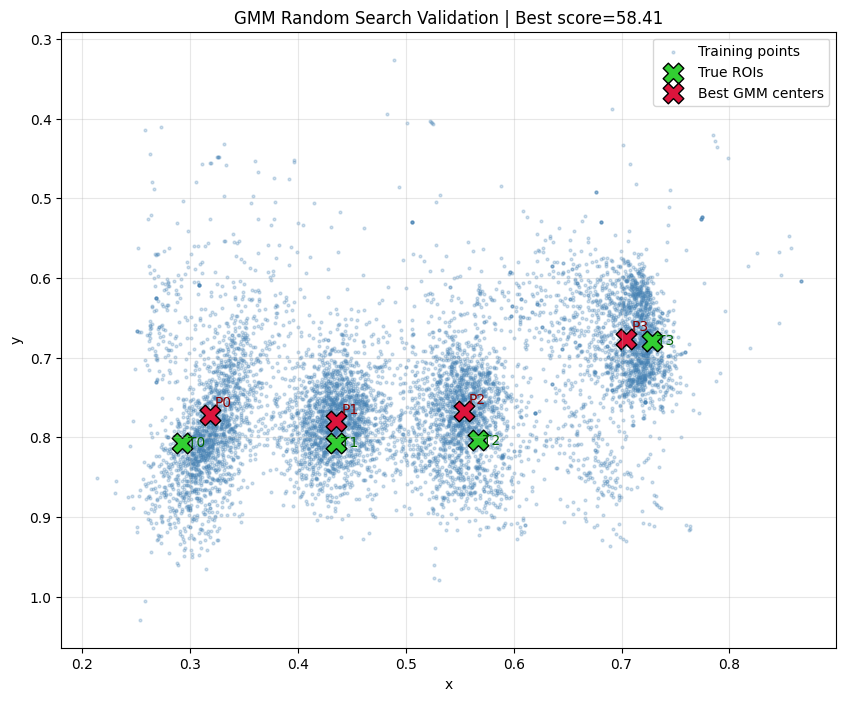


Empfohlene Hyperparameter aus Random Search:
{'n_components': 4, 'covariance_type': 'full', 'n_init': 3, 'max_iter': 400, 'reg_covar': 0.0005, 'init_params': 'kmeans', 'random_state': 83376}


In [27]:
best_row = results_df.iloc[0]
best_centers = best_row["centers"]

sample_size = min(len(X), 8000)
sample_idx = RNG.choice(len(X), size=sample_size, replace=False)
X_plot = X[sample_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_plot[:, 0], X_plot[:, 1], s=4, alpha=0.25, c="steelblue", label="Training points")
ax.scatter(TRUE_ROIS[:, 0], TRUE_ROIS[:, 1], s=220, marker="X", c="limegreen", edgecolors="black", label="True ROIs")
ax.scatter(best_centers[:, 0], best_centers[:, 1], s=220, marker="X", c="crimson", edgecolors="black", label="Best GMM centers")

for i, (tx, ty) in enumerate(TRUE_ROIS):
    ax.text(tx + 0.005, ty + 0.005, f"T{i}", fontsize=10, color="darkgreen")
for i, (px, py) in enumerate(best_centers):
    ax.text(px + 0.005, py - 0.01, f"P{i}", fontsize=10, color="darkred")

ax.set_title(f"GMM Random Search Validation | Best score={best_row['score']:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.invert_yaxis()
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.show()

print("\nEmpfohlene Hyperparameter aus Random Search:")
print({
    "n_components": int(best_row["n_components"]),
    "covariance_type": best_row["covariance_type"],
    "n_init": int(best_row["n_init"]),
    "max_iter": int(best_row["max_iter"]),
    "reg_covar": float(best_row["reg_covar"]),
    "init_params": best_row["init_params"],
    "random_state": int(SEED),
})